# Three-method comparison diagnostics

Place this notebook in the same directory as `monolithic_benders_lbbd_comparison.xlsx`, or change `WORKBOOK` below. It searches all sheets for the manuscript-relevant metrics, computes method differences, checks solver-gap coverage, and flags objective-accounting inconsistencies.

In [1]:
from pathlib import Path
import math
import pandas as pd
import numpy as np

WORKBOOK = Path('2026-09-08_102940_monolithic_benders_lbbd_comparison.xlsx')
assert WORKBOOK.exists(), f'Workbook not found: {WORKBOOK.resolve()}'
xls = pd.ExcelFile(WORKBOOK)
print(xls.sheet_names)


['Requested comparison', 'Raw metrics', 'Run folders', 'Computational summary', 'Build timing', 'Redirection complexity', 'Solver complexity', 'Solver log detail', 'Preprocessing scalars', 'Benders complexity', 'LBBD complexity', 'Efficiency summary']


In [2]:
def norm(x):
    if pd.isna(x): return ''
    return str(x).strip().lower().replace('\u00a0', ' ')

def as_num(x):
    if pd.isna(x): return np.nan
    if isinstance(x, (int, float, np.number)): return float(x)
    s = str(x).strip().replace('\u00a0', '').replace(' ', '')
    if s.endswith('%'):
        s = s[:-1]
        pct = True
    else:
        pct = False
    if ',' in s and '.' not in s:
        s = s.replace(',', '.')
    elif ',' in s and '.' in s:
        s = s.replace(',', '')
    try:
        v = float(s)
        return v / 100 if pct else v
    except Exception:
        return np.nan

sheets = {name: pd.read_excel(WORKBOOK, sheet_name=name, header=None) for name in xls.sheet_names}

def find_metric(metric):
    target = norm(metric)
    hits = []
    for sname, df in sheets.items():
        for r in range(len(df)):
            row = df.iloc[r]
            for c, val in enumerate(row):
                if norm(val) == target:
                    hits.append((sname, r, c, row.tolist()))
    return hits

for m in ['Net Profit (Obj)', 'annual_profit_SEK', 'Total runtime', 'Peak process-tree RSS', 'master_objective_SEK']:
    print('\n', m, find_metric(m)[:3])



 Net Profit (Obj) [('Requested comparison', 32, 0, ['Net Profit (Obj)', 126991945.9743704, 126991462.4474, 126991930.8898037, -483.5269704163074, -3.807540444445926e-06, -15.08456671237946, -1.18783648810483e-07, 468.442403703928, 3.688770840779609e-06])]

 annual_profit_SEK [('Raw metrics', 11, 0, ['annual_profit_SEK', 126991945.9743704, 126991462.4474, 126991930.8898037, -483.5269704163074, -3.807540444445926e-06, -15.08456671237946, -1.18783648810483e-07, 468.442403703928, 3.688770840779609e-06])]

 Total runtime [('Computational summary', 1, 0, ['Total runtime', 's', 1209.699804399861, 39529.59240789991, 3166.20529549988]), ('Benders complexity', 27, 1, ['Observed execution', 'Total runtime', 'Build + solve + export + figures', 39529.59240789991, 's', nan]), ('LBBD complexity', 32, 1, ['Observed execution', 'Total runtime', 'Build + decomposition + export + figures', 3166.20529549988, 's', nan])]

 Peak process-tree RSS [('Computational summary', 2, 0, ['Peak process-tree RSS', 'M

In [3]:
metric_names = [
    'Slow chargers (11 kW)', 'Medium chargers (22 kW)', 'Fast chargers (50 kW)',
    'PV panels (500 W)', 'Battery units (10 kWh)',
    'Grid electricity purchase', 'PV generated locally', 'Battery Discharge',
    'Public demand redirected', 'Share of redirected public demand',
    'Public charging revenue', 'Grid electricity cost', 'Redirection incentive',
    'Annual CapEx chargers', 'Annual CapEx (PV + BESS)', 'Net Profit (Obj)',
    'Total runtime', 'Peak process-tree RSS', 'Initial solver rows',
    'Initial solver columns', 'Initial solver nonzeros', 'Total primary-role solver time',
    'Total primary-role nodes', 'Total primary-role work units'
]

rows = []
for metric in metric_names:
    hits = find_metric(metric)
    if not hits:
        rows.append([metric, np.nan, np.nan, np.nan])
        continue
    sname, r, c, row = hits[0]
    vals = [as_num(v) for v in row[c+1:c+8]]
    nums = [v for v in vals if not np.isnan(v)]
    if metric in ['Total runtime','Peak process-tree RSS','Initial solver rows','Initial solver columns','Initial solver nonzeros','Total primary-role solver time','Total primary-role nodes','Total primary-role work units']:
        # computational tables often have a Unit column immediately after Metric
        vals2 = [as_num(v) for v in row[c+2:c+5]]
        if sum(not np.isnan(v) for v in vals2) == 3:
            nums = vals2
    if len(nums) >= 3:
        rows.append([metric, nums[0], nums[1], nums[2]])
    else:
        rows.append([metric, np.nan, np.nan, np.nan])

out = pd.DataFrame(rows, columns=['Metric','Monolithic','Benders','LBBD'])
out['Benders_abs_diff'] = out.Benders - out.Monolithic
out['LBBD_abs_diff'] = out.LBBD - out.Monolithic
out['Benders_rel_%'] = 100 * out.Benders_abs_diff / out.Monolithic.abs()
out['LBBD_rel_%'] = 100 * out.LBBD_abs_diff / out.Monolithic.abs()
out


,Metric,Monolithic,Benders,LBBD,Benders_abs_diff,LBBD_abs_diff,Benders_rel_%,LBBD_rel_%
0,Slow chargers (11 kW),7.200000e+01,7.200000e+01,7.200000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000
1,Medium chargers (22 kW),4.020000e+02,4.020000e+02,4.020000e+02,0.000000e+00,0.000000e+00,0.000000,0.000000
2,Fast chargers (50 kW),4.100000e+01,4.100000e+01,4.100000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000
3,PV panels (500 W),1.508500e+04,1.507500e+04,1.508900e+04,-1.000000e+01,4.000000e+00,-0.066291,0.026516
4,Battery units (10 kWh),3.210000e+02,3.210000e+02,3.200000e+02,0.000000e+00,-1.000000e+00,0.000000,-0.311526
5,Grid electricity purchase,2.270754e+07,2.271026e+07,2.270677e+07,2.715433e+03,-7.745399e+02,0.011958,-0.003411
6,PV generated locally,6.603792e+06,6.600887e+06,6.604616e+06,-2.904168e+03,8.247355e+02,-0.043977,0.012489
7,Battery Discharge,1.374606e+06,1.372842e+06,1.375412e+06,-1.764383e+03,8.057508e+02,-0.128356,0.058617
8,Public demand redirected,4.552038e+05,4.551373e+05,4.556392e+05,-6.647826e+01,4.354059e+02,-0.014604,0.095651
9,Share of redirected public demand,1.791469e-02,1.791207e-02,1.793182e-02,-2.616273e-06,1.713554e-05,-0.014604,0.095651


In [4]:
# Manuscript-ready headline statistics
def getv(metric, method):
    return float(out.loc[out.Metric.eq(metric), method].iloc[0])

mono_obj = getv('Net Profit (Obj)', 'Monolithic')
bend_obj = getv('Net Profit (Obj)', 'Benders')
lbbd_obj = getv('Net Profit (Obj)', 'LBBD')
mono_rt = getv('Total runtime', 'Monolithic')
bend_rt = getv('Total runtime', 'Benders')
lbbd_rt = getv('Total runtime', 'LBBD')
mono_mem = getv('Peak process-tree RSS', 'Monolithic')
bend_mem = getv('Peak process-tree RSS', 'Benders')
lbbd_mem = getv('Peak process-tree RSS', 'LBBD')

summary = pd.DataFrame({
    'statistic': [
        'Benders objective difference vs monolithic (%)',
        'LBBD objective difference vs monolithic (%)',
        'LBBD runtime reduction vs monolithic (%)',
        'LBBD runtime factor vs Benders',
        'LBBD peak-RSS reduction vs monolithic (%)',
        'LBBD peak-RSS reduction vs Benders (%)'
    ],
    'value': [
        100*(bend_obj-mono_obj)/abs(mono_obj),
        100*(lbbd_obj-mono_obj)/abs(mono_obj),
        100*(mono_rt-lbbd_rt)/mono_rt,
        bend_rt/lbbd_rt,
        100*(mono_mem-lbbd_mem)/mono_mem,
        100*(bend_mem-lbbd_mem)/bend_mem
    ]
})
summary


,statistic,value
0,Benders objective difference vs monolithic (%),-0.000381
1,LBBD objective difference vs monolithic (%),-0.000012
2,LBBD runtime reduction vs monolithic (%),-161.734794
3,LBBD runtime factor vs Benders,12.484848
4,LBBD peak-RSS reduction vs monolithic (%),19.368235
5,LBBD peak-RSS reduction vs Benders (%),34.302500


In [5]:
# Objective-accounting diagnostic
def first_scalar(metric):
    hits = find_metric(metric)
    if not hits: return np.nan
    row = hits[0][3]
    vals = [as_num(v) for v in row]
    return vals

hits_master = find_metric('master_objective_SEK')
hits_price = find_metric('redirection_price_compensation_SEK')
hits_profit = find_metric('annual_profit_SEK')

if hits_master and hits_price and hits_profit:
    # assumes comparison-row order Metric, Monolithic, Benders, LBBD, ...
    master_row = hits_master[0][3]
    price_row = hits_price[0][3]
    profit_row = hits_profit[0][3]
    b_master = as_num(master_row[2])
    b_price = as_num(price_row[2])
    b_profit = as_num(profit_row[2])
    print('Benders master objective:', b_master)
    print('Benders annual profit:', b_profit)
    print('Difference:', b_master - b_profit)
    print('Benders price compensation:', b_price)
    print('Difference minus price compensation:', (b_master - b_profit) - b_price)
else:
    print('One or more accounting metrics were not found.')


Benders master objective: 126991862.5443514
Benders annual profit: 126991462.4474
Difference: 400.0969513952732
Benders price compensation: 400.0969513547739
Difference minus price compensation: 4.049928747917875e-08


In [6]:
# Export concise tables for manuscript/rebuttal use
out.to_csv('manuscript_method_comparison.csv', index=False)
summary.to_csv('manuscript_headline_stats.csv', index=False)
print('Wrote manuscript_method_comparison.csv and manuscript_headline_stats.csv')


Wrote manuscript_method_comparison.csv and manuscript_headline_stats.csv


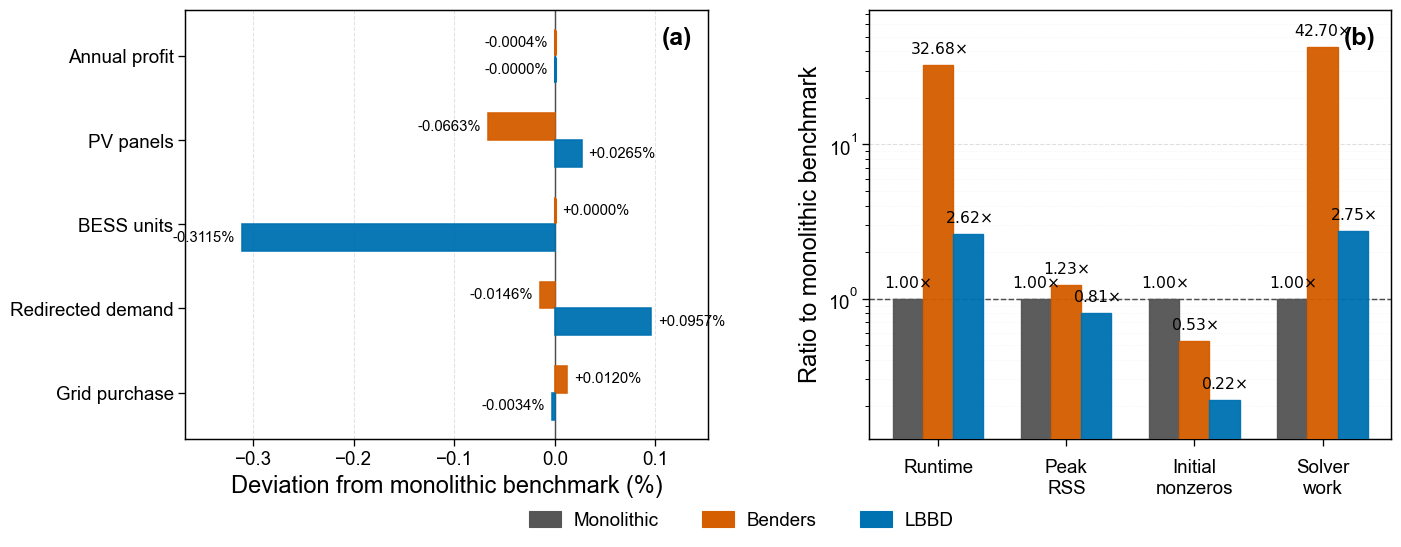

PDF: C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\comparisons\three_method_validation_figures\three_method_validation_compound_final_v2.pdf
PNG: C:\Users\omkarp\IdeaProjects\VSCode\Large-scale-LBBD-Optimization\runs\comparisons\three_method_validation_figures\three_method_validation_compound_final_v2_600dpi.png


In [9]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.ticker import LogLocator, NullFormatter
from matplotlib.patches import Patch

# ============================================================
# LOAD DATA
# ============================================================

if "out" not in globals():
    out = pd.read_csv("manuscript_method_comparison.csv")

methods = ["Monolithic", "Benders", "LBBD"]

def value(metric, method):
    row = out.loc[out["Metric"].eq(metric), method]
    if row.empty:
        raise KeyError(f"Metric not found: {metric}")
    return float(row.iloc[0])


# ============================================================
# PUBLICATION STYLE
# ============================================================

COLORS = {
    "Monolithic": "#555555",
    "Benders": "#D55E00",
    "LBBD": "#0072B2",
}

mpl.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 17,
    "xtick.labelsize": 13.5,
    "ytick.labelsize": 13.5,
    "legend.fontsize": 13.5,
    "axes.linewidth": 1.05,
    "lines.linewidth": 2.0,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "mathtext.fontset": "dejavusans",
    "font.family": "sans-serif",
    "font.sans-serif": [
        "Arial",
        "Helvetica",
        "DejaVu Sans"
    ],
})

fig, axes = plt.subplots(
    1,
    2,
    figsize=(13.4, 5.65),
)


# ============================================================
# (a) SOLUTION VALIDATION
# Percentage deviation from monolithic benchmark
# ============================================================

validation_metrics = [
    ("Net Profit (Obj)", "Annual profit"),
    ("PV panels (500 W)", "PV panels"),
    ("Battery units (10 kWh)", "BESS units"),
    ("Public demand redirected", "Redirected demand"),
    ("Grid electricity purchase", "Grid purchase"),
]

validation_labels = [label for _, label in validation_metrics]

benders_dev = []
lbbd_dev = []

for metric, _ in validation_metrics:

    mono = value(metric, "Monolithic")
    bend = value(metric, "Benders")
    lbbd = value(metric, "LBBD")

    benders_dev.append(
        100.0 * (bend - mono) / abs(mono)
    )

    lbbd_dev.append(
        100.0 * (lbbd - mono) / abs(mono)
    )

y = np.arange(len(validation_labels))
bar_h = 0.32

bars_b = axes[0].barh(
    y - bar_h / 2,
    benders_dev,
    height=bar_h,
    color=COLORS["Benders"],
    edgecolor=COLORS["Benders"],
    linewidth=1.15,
    alpha=0.96,
    zorder=3,
)

bars_l = axes[0].barh(
    y + bar_h / 2,
    lbbd_dev,
    height=bar_h,
    color=COLORS["LBBD"],
    edgecolor=COLORS["LBBD"],
    linewidth=1.15,
    alpha=0.96,
    zorder=3,
)

axes[0].axvline(
    0,
    color="0.30",
    linewidth=1.05,
    zorder=2,
)

axes[0].set_yticks(y)
axes[0].set_yticklabels(validation_labels)
axes[0].invert_yaxis()

axes[0].set_xlabel(
    "Deviation from monolithic benchmark (%)"
)

axes[0].set_axisbelow(True)

axes[0].grid(
    True,
    axis="x",
    which="major",
    linestyle="--",
    linewidth=0.75,
    color="0.55",
    alpha=0.25,
)

# ------------------------------------------------------------
# Improve visibility of extremely narrow bars without
# changing their numerical width.
# ------------------------------------------------------------

visible_tip_threshold = 0.003

for bars, vals, color in [
    (bars_b, benders_dev, COLORS["Benders"]),
    (bars_l, lbbd_dev, COLORS["LBBD"]),
]:

    for bar, v in zip(bars, vals):

        yc = bar.get_y() + bar.get_height() / 2

        if abs(v) < visible_tip_threshold:
            axes[0].vlines(
                v,
                yc - bar_h * 0.46,
                yc + bar_h * 0.46,
                color=color,
                linewidth=2.2,
                zorder=5,
            )

# ------------------------------------------------------------
# Data labels
# ------------------------------------------------------------

all_dev = np.asarray(benders_dev + lbbd_dev)
max_abs_dev = np.nanmax(np.abs(all_dev))

label_pad = max(max_abs_dev * 0.022, 0.004)

for bars, vals in [
    (bars_b, benders_dev),
    (bars_l, lbbd_dev),
]:

    for bar, v in zip(bars, vals):

        yc = bar.get_y() + bar.get_height() / 2

        if v >= 0:
            x_text = v + label_pad
            ha = "left"
        else:
            x_text = v - label_pad
            ha = "right"

        axes[0].text(
            x_text,
            yc,
            f"{v:+.4f}%",
            ha=ha,
            va="center",
            fontsize=10.7,
        )

xmin, xmax = axes[0].get_xlim()
span = xmax - xmin

axes[0].set_xlim(
    xmin - 0.08 * span,
    xmax + 0.08 * span,
)

axes[0].text(
    0.97,
    0.96,
    "(a)",
    transform=axes[0].transAxes,
    fontsize=18,
    fontweight="bold",
    ha="right",
    va="top",
)


# ============================================================
# (b) COMPUTATIONAL BURDEN
# Ratio relative to monolithic benchmark
# ============================================================

effort_metrics = [
    ("Total runtime", "Runtime"),
    ("Peak process-tree RSS", "Peak\nRSS"),
    ("Initial solver nonzeros", "Initial\nnonzeros"),
    ("Total primary-role work units", "Solver\nwork"),
]

effort_labels = [label for _, label in effort_metrics]

ratios = {
    method: []
    for method in methods
}

for metric, _ in effort_metrics:

    mono = value(metric, "Monolithic")

    for method in methods:
        ratios[method].append(
            value(metric, method) / mono
        )

x = np.arange(len(effort_labels))
width = 0.235

offsets = {
    "Monolithic": -width,
    "Benders": 0.0,
    "LBBD": width,
}

bar_containers = {}

for method in methods:

    bc = axes[1].bar(
        x + offsets[method],
        ratios[method],
        width=width,
        color=COLORS[method],
        edgecolor=COLORS[method],
        linewidth=1.0,
        alpha=0.96,
        zorder=3,
    )

    bar_containers[method] = bc


# ------------------------------------------------------------
# Logarithmic ratio axis
# ------------------------------------------------------------

axes[1].set_yscale("log")

axes[1].set_xticks(x)

axes[1].set_xticklabels(
    effort_labels,
    rotation=0,
    ha="center",
    multialignment="center",
)

axes[1].tick_params(
    axis="x",
    pad=9,
)

axes[1].set_ylabel(
    "Ratio to monolithic benchmark"
)

axes[1].axhline(
    1.0,
    color="0.30",
    linestyle="--",
    linewidth=1.05,
    zorder=2,
)

axes[1].yaxis.set_major_locator(
    LogLocator(
        base=10.0,
        subs=(1.0,)
    )
)

axes[1].yaxis.set_minor_locator(
    LogLocator(
        base=10.0,
        subs=np.arange(2, 10) * 0.1,
        numticks=100,
    )
)

axes[1].yaxis.set_minor_formatter(
    NullFormatter()
)

axes[1].set_axisbelow(True)

axes[1].grid(
    True,
    axis="y",
    which="major",
    linestyle="--",
    linewidth=0.8,
    color="0.55",
    alpha=0.28,
)

axes[1].grid(
    True,
    axis="y",
    which="minor",
    linestyle=":",
    linewidth=0.5,
    color="0.60",
    alpha=0.15,
)


# ------------------------------------------------------------
# Add deliberate headroom so the largest Benders label
# remains comfortably inside the plotting area.
# ------------------------------------------------------------

all_ratios = np.asarray(
    [
        r
        for method in methods
        for r in ratios[method]
    ],
    dtype=float,
)

positive_ratios = all_ratios[
    np.isfinite(all_ratios)
    & (all_ratios > 0)
]

ymin = positive_ratios.min()
ymax = positive_ratios.max()

axes[1].set_ylim(
    bottom=ymin / 1.8,
    top=ymax * 1.75,
)


# ------------------------------------------------------------
# Ratio labels
# Use a true multiplication symbol via MathText.
# ------------------------------------------------------------

for method in methods:

    for bar, ratio in zip(
        bar_containers[method],
        ratios[method],
    ):

        if method == "Monolithic":
            numeric_part = "1.00"
        else:
            numeric_part = f"{ratio:.2f}"

        ratio_label = (
            rf"{numeric_part}$\times$"
        )

        axes[1].annotate(
            ratio_label,
            xy=(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height(),
            ),
            xytext=(0, 6),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=11.2,
            fontweight="medium",
            fontfamily="DejaVu Sans",
            clip_on=False,
        )

axes[1].text(
    0.97,
    0.96,
    "(b)",
    transform=axes[1].transAxes,
    fontsize=18,
    fontweight="bold",
    ha="right",
    va="top",
)


# ============================================================
# COMMON FIGURE-LEVEL LEGEND
# ============================================================

legend_handles = [
    Patch(
        facecolor=COLORS["Monolithic"],
        edgecolor=COLORS["Monolithic"],
        label="Monolithic",
    ),
    Patch(
        facecolor=COLORS["Benders"],
        edgecolor=COLORS["Benders"],
        label="Benders",
    ),
    Patch(
        facecolor=COLORS["LBBD"],
        edgecolor=COLORS["LBBD"],
        label="LBBD",
    ),
]

fig.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.015),
    ncols=3,
    frameon=False,
    handlelength=1.7,
    handleheight=0.9,
    columnspacing=2.3,
    handletextpad=0.7,
)


# ============================================================
# FINAL LAYOUT
# ============================================================

for ax in axes:

    ax.tick_params(
        direction="out",
        length=5.0,
        width=0.95,
    )

    ax.tick_params(
        which="minor",
        length=2.8,
        width=0.7,
    )

fig.subplots_adjust(
    left=0.085,
    right=0.985,
    top=0.965,
    bottom=0.205,
    wspace=0.31,
)

output_dir = Path(
    "three_method_validation_figures"
)

output_dir.mkdir(
    parents=True,
    exist_ok=True,
)

pdf_path = (
    output_dir
    / "three_method_validation_compound_final_v2.pdf"
)

png_path = (
    output_dir
    / "three_method_validation_compound_final_v2_600dpi.png"
)

fig.savefig(
    pdf_path,
    format="pdf",
    bbox_inches="tight",
)

fig.savefig(
    png_path,
    dpi=600,
    bbox_inches="tight",
)

plt.show()

print(f"PDF: {pdf_path.resolve()}")
print(f"PNG: {png_path.resolve()}")